# Semaine 3 — Baseline, modèles & évaluation rigoureuse ⭐

**Jalon clé :** un modèle ML n'a de valeur que s'il **bat une baseline naïve**. On va plus loin que « entraîner-prédire » : cross-validation **temporelle**, **learning curve** et **validation curve** pour choisir le bon modèle et diagnostiquer **sous-apprentissage / sur-apprentissage**.

Données : la table `features + target` de la semaine 2.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, learning_curve, validation_curve

from parking.config import DATA_PROCESSED

# Trié par temps : indispensable pour la cross-validation temporelle
df = pd.read_parquet(DATA_PROCESSED / "occupancy_features_2019_subset.parquet")
df = df.sort_values("slot").reset_index(drop=True)
df["street_code"] = df["street_name"].astype("category").cat.codes

FEATURES = ["street_code", "hour", "minute", "day_of_week", "is_weekend", "month"]
TARGET = "occupancy_rate"
print(f"{len(df):,} lignes | cible '{TARGET}' : moyenne {df[TARGET].mean():.3f}, écart-type {df[TARGET].std():.3f}")

140,163 lignes | cible 'occupancy_rate' : moyenne 0.871, écart-type 0.158


## 1. Split temporel (hold-out final)

On réserve **octobre→décembre** comme test final (jamais vu pendant l'entraînement ni la sélection de modèle). On entraîne / valide sur **janvier→septembre**. On ne mélange jamais passé et futur (sinon fuite de données).

In [2]:
cutoff = pd.Timestamp("2019-10-01")
train = df[df["slot"] < cutoff]
test = df[df["slot"] >= cutoff]
X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]
print(f"Train : {len(X_train):,} ({train['slot'].min().date()} → {train['slot'].max().date()})")
print(f"Test  : {len(X_test):,} ({test['slot'].min().date()} → {test['slot'].max().date()})")


def evaluate(y_true, y_pred) -> dict:
    """MAE, RMSE, R² en un coup."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

Train : 104,832 (2019-01-01 → 2019-09-30)
Test  : 35,331 (2019-10-01 → 2020-01-01)


## 2. Baselines (référence à battre)

Trois niveaux, du plus naïf au plus fin. La 3ᵉ (moyenne historique par rue × heure × jour) est **la** baseline du plan.

In [3]:
street_mean = train.groupby("street_code")[TARGET].mean()
hist = train.groupby(["street_code", "hour", "day_of_week"])[TARGET].mean().rename("pred")

pred_global = np.full(len(test), y_train.mean())
pred_street = test["street_code"].map(street_mean).to_numpy()
pred_hist = (
    test.merge(hist, on=["street_code", "hour", "day_of_week"], how="left")["pred"]
    .fillna(test["street_code"].map(street_mean))
    .fillna(y_train.mean())
    .to_numpy()
)

scores = {
    "Moyenne globale": evaluate(y_test, pred_global),
    "Moyenne par rue": evaluate(y_test, pred_street),
    "Baseline (rue,heure,jour)": evaluate(y_test, pred_hist),
}
pd.DataFrame(scores).T.round(4)

,MAE,RMSE,R2
Moyenne globale,0.0980,0.1218,-0.0272
Moyenne par rue,0.0802,0.1121,0.1299
"Baseline (rue,heure,jour)",0.0662,0.0953,0.3705


## 3. Modèles + diagnostic sur/sous-apprentissage (train vs test)

On compare Random Forest et HistGradientBoosting. On regarde l'écart **train vs test** : un grand écart = sur-apprentissage (overfitting) ; train ≈ test mais erreur élevée = sous-apprentissage (underfitting).

In [4]:
models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
}
rows = []
for name, m in models.items():
    m.fit(X_train, y_train)
    tr = evaluate(y_train, m.predict(X_train))
    te = evaluate(y_test, m.predict(X_test))
    rows.append({"modèle": name, "MAE_train": tr["MAE"], "MAE_test": te["MAE"],
                 "écart": te["MAE"] - tr["MAE"], "R2_test": te["R2"]})
pd.DataFrame(rows).set_index("modèle").round(4)

,MAE_train,MAE_test,écart,R2_test
modèle,,,,
RandomForest,0.0561,0.0571,0.001,0.4302
HistGradientBoosting,0.0596,0.0547,-0.005,0.4574


## 4. Cross-validation temporelle

Un seul hold-out peut être chanceux/malchanceux. On valide avec **`TimeSeriesSplit`** : chaque fold entraîne sur le passé et valide sur le futur immédiat (jamais l'inverse). On regarde la **moyenne ± écart-type** de la MAE.

In [5]:
tscv = TimeSeriesSplit(n_splits=5)
for name, m in models.items():
    sc = -cross_val_score(m, X_train, y_train, cv=tscv,
                          scoring="neg_mean_absolute_error", n_jobs=-1)
    print(f"{name:22} MAE CV = {sc.mean():.4f} ± {sc.std():.4f}   (folds: {np.round(sc, 4)})")

RandomForest           MAE CV = 0.0720 ± 0.0278   (folds: [0.1166 0.0883 0.0673 0.0429 0.0447])


HistGradientBoosting   MAE CV = 0.0694 ± 0.0274   (folds: [0.1132 0.0849 0.0669 0.0396 0.0426])


## 5. Learning curve — a-t-on assez de données ?

On trace l'erreur (train et validation) en fonction de la taille du jeu d'entraînement.
- Les deux courbes hautes et proches → **sous-apprentissage** (modèle trop simple / features pauvres).
- Grand écart entre les deux → **sur-apprentissage** (plus de données aiderait).

(Sur HistGradientBoosting, rapide.)

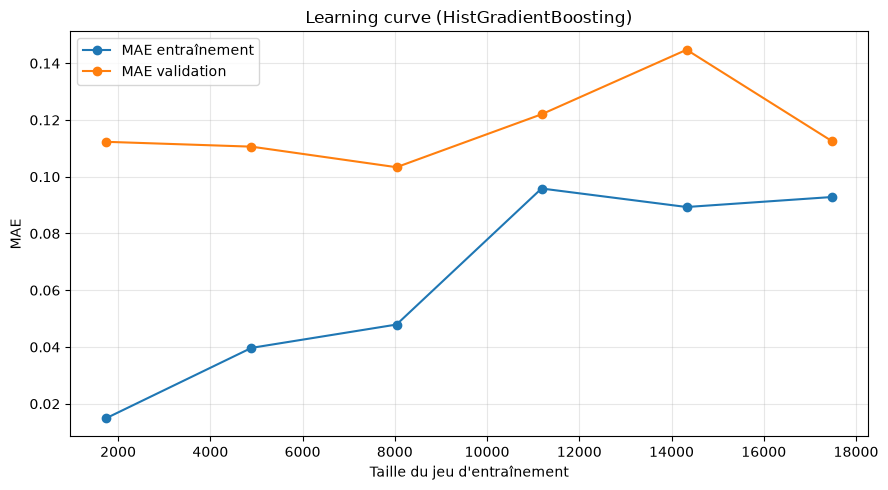

In [6]:
sizes, train_sc, val_sc = learning_curve(
    HistGradientBoostingRegressor(random_state=42), X_train, y_train,
    cv=TimeSeriesSplit(n_splits=5), scoring="neg_mean_absolute_error",
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1,
)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sizes, -train_sc.mean(1), "o-", label="MAE entraînement")
ax.plot(sizes, -val_sc.mean(1), "o-", label="MAE validation")
ax.set_xlabel("Taille du jeu d'entraînement")
ax.set_ylabel("MAE")
ax.set_title("Learning curve (HistGradientBoosting)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Validation curve — choisir la complexité (`max_depth`)

On fait varier la profondeur maximale des arbres. On cherche le point où la MAE de validation est minimale : trop peu profond = sous-apprentissage, trop profond = sur-apprentissage.

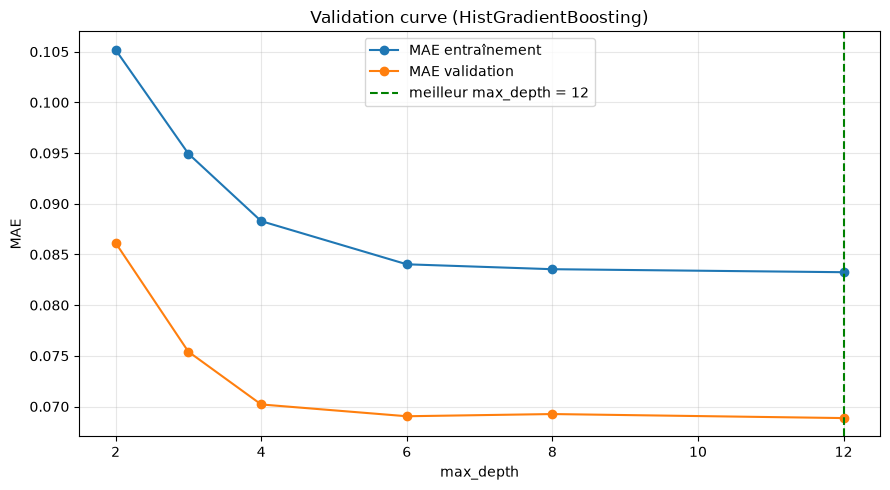

Meilleur max_depth : 12


In [7]:
depths = [2, 3, 4, 6, 8, 12]
tr_sc, va_sc = validation_curve(
    HistGradientBoostingRegressor(random_state=42), X_train, y_train,
    param_name="max_depth", param_range=depths,
    cv=TimeSeriesSplit(n_splits=5), scoring="neg_mean_absolute_error", n_jobs=-1,
)
tr_mae, va_mae = -tr_sc.mean(1), -va_sc.mean(1)
best_depth = depths[int(np.argmin(va_mae))]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depths, tr_mae, "o-", label="MAE entraînement")
ax.plot(depths, va_mae, "o-", label="MAE validation")
ax.axvline(best_depth, color="green", ls="--", label=f"meilleur max_depth = {best_depth}")
ax.set_xlabel("max_depth")
ax.set_ylabel("MAE")
ax.set_title("Validation curve (HistGradientBoosting)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Meilleur max_depth :", best_depth)

## 7. Modèle final & verdict sur le hold-out

On entraîne le modèle réglé sur janvier→septembre et on l'évalue sur octobre→décembre (jamais vu), face à la baseline.

In [8]:
final = HistGradientBoostingRegressor(max_depth=best_depth, random_state=42)
final.fit(X_train, y_train)
pred_final = final.predict(X_test)

scores["Modèle final (HGB réglé)"] = evaluate(y_test, pred_final)
table = pd.DataFrame(scores).T.round(4).sort_values("MAE")
base_mae = scores["Baseline (rue,heure,jour)"]["MAE"]
table["gain_vs_baseline_%"] = ((base_mae - table["MAE"]) / base_mae * 100).round(1)
table

,MAE,RMSE,R2,gain_vs_baseline_%
Modèle final (HGB réglé),0.0548,0.0886,0.4560,17.2
"Baseline (rue,heure,jour)",0.0662,0.0953,0.3705,-0.0
Moyenne par rue,0.0802,0.1121,0.1299,-21.2
Moyenne globale,0.0980,0.1218,-0.0272,-48.1


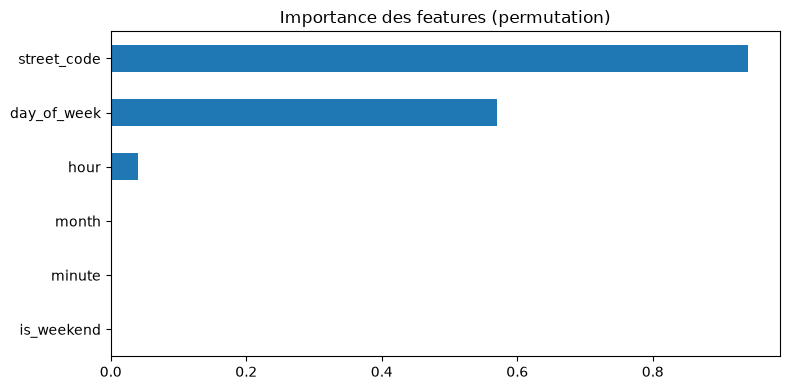

In [9]:
# Importance par permutation (plus fiable que l'importance d'impureté)
perm = permutation_importance(final, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)
imp.plot.barh(figsize=(8, 4), title="Importance des features (permutation)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

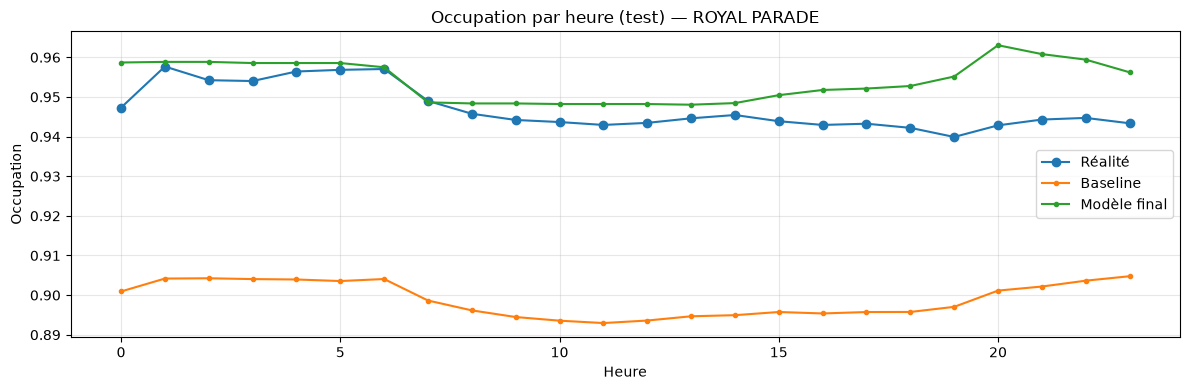

In [10]:
# Vérification visuelle : réalité vs baseline vs modèle (une rue, période de test)
viz = test.copy()
viz["baseline"] = pred_hist
viz["modele"] = pred_final
s = viz["street_code"].value_counts().index[0]
one = viz[viz["street_code"] == s]
name = df.loc[df["street_code"] == s, "street_name"].iloc[0]
fig, ax = plt.subplots(figsize=(12, 4))
one.groupby("hour")["occupancy_rate"].mean().plot(ax=ax, marker="o", label="Réalité")
one.groupby("hour")["baseline"].mean().plot(ax=ax, marker=".", label="Baseline")
one.groupby("hour")["modele"].mean().plot(ax=ax, marker=".", label="Modèle final")
ax.set_title(f"Occupation par heure (test) — {name}")
ax.set_xlabel("Heure"); ax.set_ylabel("Occupation"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Conclusions

**Le jalon est atteint : le modèle bat la baseline ✅**

| Méthode | MAE | RMSE | R² | vs baseline |
|---|---|---|---|---|
| Moyenne globale | 0,0980 | 0,122 | −0,03 | −48 % |
| Moyenne par rue | 0,0802 | 0,112 | 0,13 | −21 % |
| **Baseline (rue,heure,jour)** | **0,0662** | 0,095 | 0,37 | référence |
| **Modèle final (HGB, max_depth=12)** | **0,0548** | 0,089 | **0,46** | **+17,2 %** |

**Diagnostic sur/sous-apprentissage**
- **Aucun sur-apprentissage** : MAE train ≈ test (HGB : train 0,0596 vs test 0,0547 → même un léger *sous-apprentissage*).
- **Learning curve** : courbes train/validation proches et en plateau → plus de données n'aiderait quasiment pas. Le facteur limitant, ce sont **les features**.
- **Validation curve** : meilleur `max_depth = 12`, pas de divergence train/validation.

**D'où vient le pouvoir prédictif (importance par permutation, sur le test)**
- `street_code` **0,94**, `day_of_week` 0,57, `hour` 0,04, `month` ~0, `minute`/`is_weekend` ~0.
- ⚠️ Le gain ne vient **pas** de la saisonnalité : `month` est ~inutile sur le test car les mois oct-déc sont **inconnus** du modèle (entraîné sur jan-sep) → extrapolation. Le gain vient de `street_code` + `day_of_week`, mieux régularisés que la baseline.
- ⚠️ **Dépendance forte à l'identité de la rue** : sans `street_code`, MAE 0,055 → 0,081 et R² 0,46 → 0,15. Le modèle prédit surtout le « niveau typique de chaque rue ». **Conséquence : ce modèle ne se transfère pas à de nouvelles rues / villes (ex. Bordeaux).** Pour la transférabilité, remplacer l'identité de la rue par ses *caractéristiques* (nb de places, type de zone, restriction, POIs).

**Lecture honnête**
- MAE ≈ **5,5 points d'occupation**, R² **0,46** (vs 0,37 baseline). Modeste mais réel et rigoureusement validé, sur une cible très stable (~0,87).

**Cross-validation temporelle (5 folds)** : HGB 0,0694 ± 0,0274 ; RF 0,0720 ± 0,0278. Forte variance entre folds (0,11 → 0,04) car **une seule année** → premiers folds sans saisonnalité. Limite assumée.

**Leviers d'amélioration (sous-apprentissage → de meilleures features)** : encodage cyclique (sin/cos heure/jour), variables de retard (t−30 min, t−1 j, t−1 semaine), météo, événements, jours fériés ; caractéristiques de rue (pour la transférabilité) ; plusieurs années (pour la saisonnalité).

**Prochaine étape (semaine 4)** : industrialiser dans `parking.baseline`, `parking.model`, `parking.evaluation` + `make train`.